**Install Required Libraries**

In [ ]:
!pip install librosa resampy soundfile tensorflow scikit-learn matplotlib


**Import Libraries**

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt


**Load Dataset and Extract Labels**

In [ ]:
# Path to unzipped RAVDESS dataset
data_path = '/content/RAVDESS'

audio_files = []
emotions = []

# RAVDESS emotion codes
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': 'disgust',
    '08': 'surprise'
}

# Scan all audio files
for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith('.wav'):
            audio_files.append(os.path.join(root, file))
            parts = file.split('-')
            emotions.append(emotion_map[parts[2]])

# Create DataFrame
df = pd.DataFrame({'path': audio_files, 'emotion': emotions})

# Keep only the 4 target emotions
df = df[df['emotion'].isin(['happy','sad','angry','neutral'])]

df.head()


,path,emotion
5,/content/RAVDESS/Actor_24/03-01-04-02-01-01-24...,sad
6,/content/RAVDESS/Actor_24/03-01-04-01-02-01-24...,sad
9,/content/RAVDESS/Actor_24/03-01-05-01-01-01-24...,angry
10,/content/RAVDESS/Actor_24/03-01-03-01-02-01-24...,happy
12,/content/RAVDESS/Actor_24/03-01-05-02-02-01-24...,angry


**Feature Extraction (MFCCs)**

In [ ]:
def extract_features(file_path, max_pad_len=174):
    audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)

    # Pad or truncate to max_pad_len
    pad_width = max_pad_len - mfccs.shape[1]
    if pad_width > 0:
        mfccs = np.pad(mfccs, pad_width=((0,0),(0,pad_width)), mode='constant')
    else:
        mfccs = mfccs[:, :max_pad_len]

    return mfccs

# Extract features for all files
features = np.array([extract_features(f) for f in df['path']])
print("Features shape:", features.shape)


Features shape: (1344, 40, 174)


**Encode Labels**

In [ ]:
le = LabelEncoder()
y = to_categorical(le.fit_transform(df['emotion']))
print("Labels shape:", y.shape)


Labels shape: (1344, 4)


**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

# Add channel dimension for CNN
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (1075, 40, 174, 1)
X_test shape: (269, 40, 174, 1)


**Build CNN Model**

In [ ]:
input_shape = (features.shape[1], features.shape[2], 1)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2,2)),
    Dropout(0.4),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(4, activation='softmax')  # 4 emotions
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,752,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,771,972 (10.57 MB)

 Trainable params: 2,771,972 (10.57 MB)

 Non-trainable params: 0 (0.00 B)

**Train the Model with Early Stopping**

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step - accuracy: 0.2667 - loss: 57.8082 - val_accuracy: 0.2698 - val_loss: 1.6682
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3195 - loss: 1.6398 - val_accuracy: 0.2977 - val_loss: 1.6580
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3182 - loss: 1.6160 - val_accuracy: 0.3163 - val_loss: 1.6204
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3726 - loss: 1.5573 - val_accuracy: 0.3116 - val_loss: 1.5865
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4018 - loss: 1.5195 - val_accuracy: 0.3581 - val_loss: 1.5507
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4276 - loss: 1.4474 - val_accuracy: 0.4140 - val_loss: 1.4809
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4579 - loss: 1.4049 - val_accuracy: 0.4791 - val_loss: 1.4493
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4838 - loss: 1.3893 - val_accuracy: 0.4651 

**Evaluate Model**

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.8668 - loss: 0.5274
Test Accuracy: 88.10%


**Plot Training Curves**

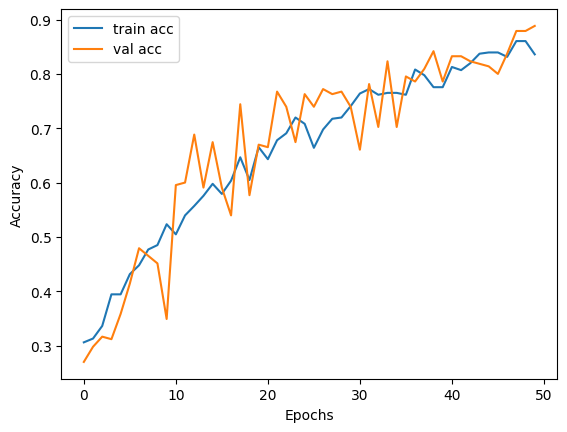

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**Predict Emotion**

In [ ]:
def predict_emotion(file_path):
    mfccs = extract_features(file_path)
    mfccs = mfccs[np.newaxis, ..., np.newaxis]  # Add batch & channel dimension
    pred = model.predict(mfccs)
    emotion = le.inverse_transform([np.argmax(pred)])
    return emotion[0]

# Example:
file_test = '/content/RAVDESS/Actor_01/03-01-03-01-01-01-01.wav'
print("Predicted Emotion:", predict_emotion(file_test))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
Predicted Emotion: happy
